Viability data (gDNA) from CRISPRko, CRISPRi CROPseq benchmark library at Day 7,14 in A549,K562s

Purpose: to verify that 1) our CROP-seq vector successfully introduces LoF by CRISPRko, CRISPRi and 2) the essential, nonessential genes targeted in this library behave as such 

Following [standard screen analysis](https://github.com/ldrepano/GPP-Jacquere/blob/main/screen_analysis_tutorial.ipynb) 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from adjustText import adjust_text
plt.rc('pdf', fonttype=42)


In [2]:
CRISPRko_readcount_filepath="../data/counts-GPP6513_BEV_A549_K562_CP2104.txt"
CRISPRi_readcount_filepath="../data/counts-GPP6513_BEV_A549_K562_CP2129.txt"
CRISPRko_readcounts=pd.read_table(CRISPRko_readcount_filepath)
CRISPRi_readcounts=pd.read_table(CRISPRi_readcount_filepath)

CRISPRko_readcounts=CRISPRko_readcounts[['Construct Barcode','CP2104 pDNA','K562_CP2104 screen 1 D14',
       'A549_CP2104 screen 1 D14']]
CRISPRi_readcounts=CRISPRi_readcounts[['Construct Barcode','CP2129 pDNA', 'K562_CP2129 screen 1 D14',
       'A549_CP2129 screen 1 D14']]
print("total # constructs, CRISPRko:", len(CRISPRko_readcounts))
print("total # constructs, CRISPRi:", len(CRISPRi_readcounts))

total # constructs, CRISPRko: 110
total # constructs, CRISPRi: 110


In [3]:
constructname_col="Construct Barcode"

CRISPRko_pDNA_col="CP2104 pDNA"
CRISPRi_pDNA_col="CP2129 pDNA"

condition_map = {'K562_CP2104 screen 1 D14': 'CRISPRko K562',
                 'A549_CP2104 screen 1 D14':'CRISPRko A549',
                 'K562_CP2129 screen 1 D14': 'CRISPRi K562',
                 'A549_CP2129 screen 1 D14':'CRISPRi A549'}

In [4]:
CRISPRko_guidemappings_filepath="../data/CRISPRko_CROPseqbenchmarklibrary.csv"
CRISPRko_guidemappings=pd.read_csv(CRISPRko_guidemappings_filepath)
guidemappings_constructname_col="sgRNA Sequence"
guidemappings_targetname_col="Target Gene Symbol"
CRISPRko_guidemappings=CRISPRko_guidemappings[[guidemappings_constructname_col,guidemappings_targetname_col]]

CRISPRko_guidemappings.head()

,sgRNA Sequence,Target Gene Symbol
0,GGAAATCGCCAGCTTCGATA,TMSB10
1,TGGCAGACAAACCAGACATG,TMSB10
2,GGCAGACAAACCAGACATGG,TMSB10
3,ATGGCAGACAAACCAGACAT,TMSB10
4,TGGGTGAAAAATATATCCGC,RPL9


In [5]:
CRISPRi_guidemappings_filepath="../data/CRISPRi_CROPseqbenchmarklibrary.csv"
CRISPRi_guidemappings=pd.read_csv(CRISPRi_guidemappings_filepath)
guidemappings_constructname_col="sgRNA Sequence"
guidemappings_targetname_col="Target Gene Symbol"
CRISPRi_guidemappings=CRISPRi_guidemappings[[guidemappings_constructname_col,guidemappings_targetname_col]]

CRISPRi_guidemappings.head()

,sgRNA Sequence,Target Gene Symbol
0,AGTGGGAGCACCAGGATCTC,TMSB10
1,GGGCTCGGAACGAGACTGCA,TMSB10
2,GAGTGGGAGCACCAGGATCT,TMSB10
3,GCAACGCGAGTGGGAGCACC,TMSB10
4,GCTGCGTCTACTGCGAGGTA,RPL9


In [6]:
# log normalize read counts 

def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6)
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads
    
CRISPRko_condition_columns = [CRISPRko_pDNA_col, 'K562_CP2104 screen 1 D14',
       'A549_CP2104 screen 1 D14']

CRISPRko_lognorm_df = CRISPRko_readcounts.copy()
CRISPRko_lognorm_df[CRISPRko_condition_columns] = CRISPRko_lognorm_df[CRISPRko_condition_columns].apply(lognorm)
CRISPRko_condition_columns.remove(CRISPRko_pDNA_col)

CRISPRi_condition_columns = [CRISPRi_pDNA_col, 'K562_CP2129 screen 1 D14',
       'A549_CP2129 screen 1 D14']

CRISPRi_lognorm_df = CRISPRi_readcounts.copy()
CRISPRi_lognorm_df[CRISPRi_condition_columns] = CRISPRi_lognorm_df[CRISPRi_condition_columns].apply(lognorm)
CRISPRi_condition_columns.remove(CRISPRi_pDNA_col)


Removing constructs underrepresented in pDNA

In [7]:
CRISPRko_filtered_lognorms = CRISPRko_lognorm_df.copy()
z_low = -3  # minimum z-score
# Z-score the pDNA column
CRISPRko_filtered_lognorms["pDNA_zscore"] = (CRISPRko_filtered_lognorms[CRISPRko_pDNA_col] - CRISPRko_filtered_lognorms[CRISPRko_pDNA_col].mean())/CRISPRko_filtered_lognorms[CRISPRko_pDNA_col].std()
# Filter by z-score
CRISPRko_filtered_lognorms = CRISPRko_filtered_lognorms[CRISPRko_filtered_lognorms["pDNA_zscore"] > z_low].reset_index(drop=True)
# Drop z-scored columns
CRISPRko_filtered_lognorms = CRISPRko_filtered_lognorms.drop("pDNA_zscore", axis=1)
print("# constructs removed due to low pDNA abundance:",len(CRISPRko_lognorm_df)-len(CRISPRko_filtered_lognorms))


# constructs removed due to low pDNA abundance: 1


In [8]:
CRISPRi_filtered_lognorms = CRISPRi_lognorm_df.copy()
z_low = -3  # minimum z-score
# Z-score the pDNA column
CRISPRi_filtered_lognorms["pDNA_zscore"] = (CRISPRi_filtered_lognorms[CRISPRi_pDNA_col] - CRISPRi_filtered_lognorms[CRISPRi_pDNA_col].mean())/CRISPRi_filtered_lognorms[CRISPRi_pDNA_col].std()
# Filter by z-score
CRISPRi_filtered_lognorms = CRISPRi_filtered_lognorms[CRISPRi_filtered_lognorms["pDNA_zscore"] > z_low].reset_index(drop=True)
# Drop z-scored columns
CRISPRi_filtered_lognorms = CRISPRi_filtered_lognorms.drop("pDNA_zscore", axis=1)
print("# constructs removed due to low pDNA abundance:",len(CRISPRi_lognorm_df)-len(CRISPRi_filtered_lognorms))


# constructs removed due to low pDNA abundance: 1


In [9]:
# calculate log fold change late time point vs. pDNA

CRISPRko_lfc_df = CRISPRko_filtered_lognorms.copy()
for col in CRISPRko_condition_columns:
    CRISPRko_lfc_df[col] = CRISPRko_filtered_lognorms[col] - CRISPRko_filtered_lognorms[CRISPRko_pDNA_col]
CRISPRko_lfc_df=CRISPRko_lfc_df.drop(CRISPRko_pDNA_col,axis=1)


CRISPRi_lfc_df = CRISPRi_filtered_lognorms.copy()
for col in CRISPRi_condition_columns:
    CRISPRi_lfc_df[col] = CRISPRi_filtered_lognorms[col] - CRISPRi_filtered_lognorms[CRISPRi_pDNA_col]
CRISPRi_lfc_df=CRISPRi_lfc_df.drop(CRISPRi_pDNA_col,axis=1)


In [10]:
CRISPRko_lfc_df_long = (CRISPRko_lfc_df.melt(id_vars=constructname_col,
                         var_name='condition', value_name='lfc'))
CRISPRko_lfc_df_long['condition'] = CRISPRko_lfc_df_long['condition'].map(condition_map)

CRISPRi_lfc_df_long = (CRISPRi_lfc_df.melt(id_vars=constructname_col,
                         var_name='condition', value_name='lfc'))
CRISPRi_lfc_df_long['condition'] = CRISPRi_lfc_df_long['condition'].map(condition_map)
CRISPRi_lfc_df_long

,Construct Barcode,condition,lfc
0,AGTGGGAGCACCAGGATCTC,CRISPRi K562,0.525056
1,GGGCTCGGAACGAGACTGCA,CRISPRi K562,0.963440
2,GAGTGGGAGCACCAGGATCT,CRISPRi K562,0.483313
3,GCAACGCGAGTGGGAGCACC,CRISPRi K562,0.818285
4,GCTGCGTCTACTGCGAGGTA,CRISPRi K562,-4.387512
...,...,...,...
213,GAAGCACTAGCCGTACGTAT,CRISPRi A549,0.236476
214,TAAATACGGTCGTTAATCCC,CRISPRi A549,-0.019659
215,TGACACGGACGTATACGGAT,CRISPRi A549,0.212121
216,TAAGGACAGGCGTATAACGA,CRISPRi A549,0.023889


In [11]:
# merge with guide mappings

CRISPRko_annotated_sgrna_lfcs = CRISPRko_guidemappings.merge(CRISPRko_lfc_df_long,how='inner',right_on=constructname_col,left_on=guidemappings_constructname_col)
if constructname_col != guidemappings_constructname_col:
    CRISPRko_annotated_sgrna_lfcs=CRISPRko_annotated_sgrna_lfcs.drop(guidemappings_constructname_col,axis=1)
CRISPRko_annotated_sgrna_lfcs["Modality"]="CRISPRko"

CRISPRi_annotated_sgrna_lfcs = CRISPRi_guidemappings.merge(CRISPRi_lfc_df_long,how='inner',right_on=constructname_col,left_on=guidemappings_constructname_col)
if constructname_col != guidemappings_constructname_col:
    CRISPRi_annotated_sgrna_lfcs=CRISPRi_annotated_sgrna_lfcs.drop(guidemappings_constructname_col,axis=1)
CRISPRi_annotated_sgrna_lfcs["Modality"]="CRISPRi"

annotated_sgrna_lfcs=pd.concat([CRISPRko_annotated_sgrna_lfcs,CRISPRi_annotated_sgrna_lfcs])
annotated_sgrna_lfcs

,Target Gene Symbol,Construct Barcode,condition,lfc,Modality
0,TMSB10,GGAAATCGCCAGCTTCGATA,CRISPRko K562,-0.275974,CRISPRko
1,TMSB10,GGAAATCGCCAGCTTCGATA,CRISPRko A549,-0.463625,CRISPRko
2,TMSB10,TGGCAGACAAACCAGACATG,CRISPRko K562,-2.314979,CRISPRko
3,TMSB10,TGGCAGACAAACCAGACATG,CRISPRko A549,-1.406859,CRISPRko
4,TMSB10,GGCAGACAAACCAGACATGG,CRISPRko K562,-1.531538,CRISPRko
...,...,...,...,...,...
213,(INTERGENIC CONTROL),TGACACGGACGTATACGGAT,CRISPRi A549,0.212121,CRISPRi
214,(INTERGENIC CONTROL),TAAGGACAGGCGTATAACGA,CRISPRi K562,0.188338,CRISPRi
215,(INTERGENIC CONTROL),TAAGGACAGGCGTATAACGA,CRISPRi A549,0.023889,CRISPRi
216,(INTERGENIC CONTROL),ACTGTGAGGTTACCTCGATA,CRISPRi K562,0.437904,CRISPRi


In [12]:
gene_lfcs = (annotated_sgrna_lfcs.groupby([guidemappings_targetname_col, 'condition'])
                     .agg(lfc_sum = ('lfc', 'sum'),
                          n_sgrnas = ('lfc', 'count'))
                     .reset_index())
gene_lfcs['gene_avg_lfc'] = (gene_lfcs['lfc_sum']/gene_lfcs['n_sgrnas'])
gene_lfcs = gene_lfcs.drop('lfc_sum', axis=1)
gene_lfcs_wide=gene_lfcs.pivot(index="Target Gene Symbol",columns="condition",values="gene_avg_lfc").reset_index()
gene_lfcs_wide

condition,Target Gene Symbol,CRISPRi A549,CRISPRi K562,CRISPRko A549,CRISPRko K562
0,(INTERGENIC CONTROL),0.231290,0.423579,0.076543,0.319685
1,AKT2,-1.632586,-1.844634,-0.472730,-0.251395
2,CNIH4,-0.937202,-1.553028,0.087166,0.457649
3,COTL1,0.330998,0.661953,0.014152,-0.092357
4,CTBP1,0.096394,-0.956546,0.175415,-0.628979
5,DCAF13,-3.577534,-3.677993,-2.529826,-2.684691
6,EPB41L2,0.505097,0.653916,0.619723,0.617167
7,ETHE1,0.469826,0.539409,0.087726,0.269282
8,GNG5,0.447289,0.785889,-0.110957,-0.140239
9,IFT25,-0.664897,-0.646916,0.499297,0.495342


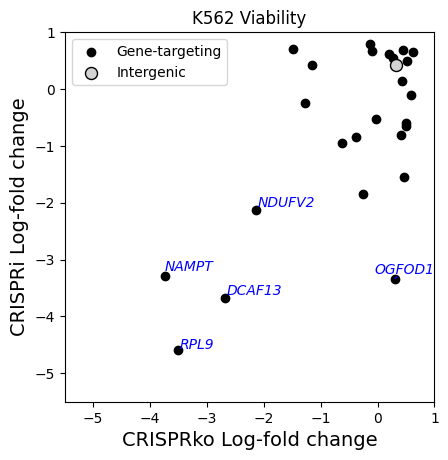

In [14]:
plt.scatter(data=gene_lfcs_wide,x="CRISPRko K562", y="CRISPRi K562",c="black",label="Gene-targeting")
plt.title("K562 Viability")
plt.xlabel("CRISPRko",fontsize=14)
plt.ylabel("CRISPRi",fontsize=14)
plt.axis("scaled")
plt.xlim(-5.5,1)
plt.ylim(-5.5,1)

#label depleted guides
xvals=gene_lfcs_wide["CRISPRko K562"].tolist()
yvals=gene_lfcs_wide["CRISPRi K562"].tolist()
texts = []
for i, txt in enumerate(gene_lfcs_wide["Target Gene Symbol"].tolist()):
    if xvals[i]<-2 or yvals[i]<-2:
        texts.append(plt.text(xvals[i], yvals[i], txt, color="blue",fontstyle="italic"))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color="blue"))

#plot negative controls
intergenic_data=gene_lfcs_wide[gene_lfcs_wide["Target Gene Symbol"]=="(INTERGENIC CONTROL)"]
plt.scatter(data=intergenic_data,x="CRISPRko K562", y="CRISPRi K562",c="lightgrey",edgecolors="black",s=75,label="Intergenic")
plt.legend()
plt.xlabel("CRISPRko Log-fold change")
plt.ylabel("CRISPRi Log-fold change")
plt.savefig("../figures/K562_Day14_logfoldchangefrompDNA_averagepertarget.pdf",dpi=600)

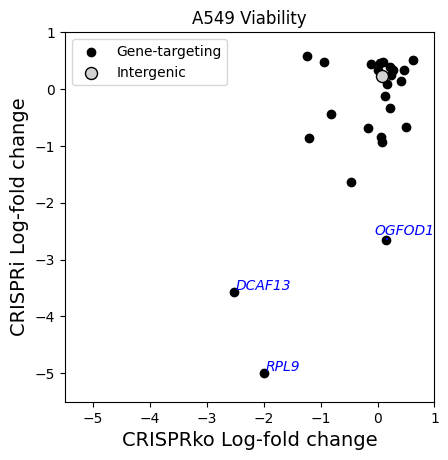

In [15]:
plt.scatter(data=gene_lfcs_wide,x="CRISPRko A549", y="CRISPRi A549",c="black",label="Gene-targeting")
plt.title("A549 Viability")
plt.xlabel("CRISPRko",fontsize=14)
plt.ylabel("CRISPRi",fontsize=14)
plt.axis("scaled")
plt.xlim(-5.5,1)
plt.ylim(-5.5,1)

#label depleted guides
xvals=gene_lfcs_wide["CRISPRko A549"].tolist()
yvals=gene_lfcs_wide["CRISPRi A549"].tolist()
texts = []
for i, txt in enumerate(gene_lfcs_wide["Target Gene Symbol"].tolist()):
    if xvals[i]<-2 or yvals[i]<-2:
        texts.append(plt.text(xvals[i], yvals[i], txt, color="blue",fontstyle="italic"))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color="blue"))

#plot negative controls
intergenic_data=gene_lfcs_wide[gene_lfcs_wide["Target Gene Symbol"]=="(INTERGENIC CONTROL)"]
plt.scatter(data=intergenic_data,x="CRISPRko A549", y="CRISPRi A549",c="lightgrey",edgecolors="black",s=75,label="Intergenic")
plt.legend()
plt.xlabel("CRISPRko Log-fold change")
plt.ylabel("CRISPRi Log-fold change")
plt.savefig("../figures/A549_Day14_logfoldchangefrompDNA_averagepertarget.pdf",dpi=600)

